# Differential Logic Part 1

blog post: https://fualsan.github.io/posts/differential-logic-part-1/

In [1]:
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.25'

%load_ext autoreload
%autoreload 2

import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

## Implementing Logic Approximations

In [2]:
x1 = jnp.array((0.50, 0.50, 0.75, 0.25))
x2 = jnp.array((0.55, 0.25, 0.15, 0.45))

In [3]:
def binarize(x):
    return jnp.where(x>=0.5, 1, 0)

In [4]:
binarize(x1)

Array([1, 1, 1, 0], dtype=int32, weak_type=True)

In [5]:
def print_binary(x):
    for x_real, x_binary in zip(x.tolist(), binarize(x).tolist()):
        x_binary_str = 'True' if x_binary == 1 else 'False'
        print(f'{x_real:2.2f} --> {x_binary:1d} ({x_binary_str})')

In [6]:
print('x1:')
print_binary(x1)
print('x2:')
print_binary(x2)

x1:
0.50 --> 1 (True)
0.50 --> 1 (True)
0.75 --> 1 (True)
0.25 --> 0 (False)
x2:
0.55 --> 1 (True)
0.25 --> 0 (False)
0.15 --> 0 (False)
0.45 --> 0 (False)


### T-Norm implementations

In [7]:
def t_norm_min(x1, x2):
    """
    Minimum (Gödel) T-norm
    """
    return jnp.minimum(x1, x2)

def t_norm_product(x1, x2):
    """
    Product T-norm
    """
    return x1*x2

def t_norm_bounded(x1, x2):
    """
    Bounded (Łukasiewicz) T-norm
    """
    return jnp.maximum(0.0, x1+x2-1.0)

### T-conorm implementations

In [8]:
def t_conorm_maximum(x1, x2):
    """
    Maximum (Gödel) T-conorm
    """
    return jnp.maximum(x1, x2)

def t_conorm_sum(x1, x2):
    """
    Probabilistic Sum
    """
    return x1+x2-x1*x2

def t_conorm_bounded(x1, x2):
    """
    Bounded (Łukasiewicz) T-conorm
    """
    return jnp.minimum(x1+x2, 1.0)

### Plots

In [9]:
def plot_norm_functions(x1, x2, norm_fn, norm_fn_name, save_name):
    X1, X2 = jnp.meshgrid(x1, x2)

    norm_output = norm_fn(X1, X2)

    fig = plt.figure(figsize=(8, 6))
    im = plt.imshow(
      norm_output,
      extent=(float(x1[0]), float(x1[-1]), float(x2[0]), float(x2[-1])),
      origin='lower',
      cmap='viridis',
      aspect='auto',
    )
    
    plt.colorbar(im, label='Truth')
    plt.xlabel(r'$X_1$')
    plt.ylabel(r'$X_2$')
    plt.title(f'2D Heatmap of {norm_fn_name}')
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(
        f'{save_name}.png',
        bbox_inches='tight', 
        dpi=300
    )

In [10]:
NUM_SAMPLES = 100
x1 = jnp.linspace(0.0, 1.0, NUM_SAMPLES)
x2 = jnp.linspace(0.0, 1.0, NUM_SAMPLES)

#### T-Norm Plots

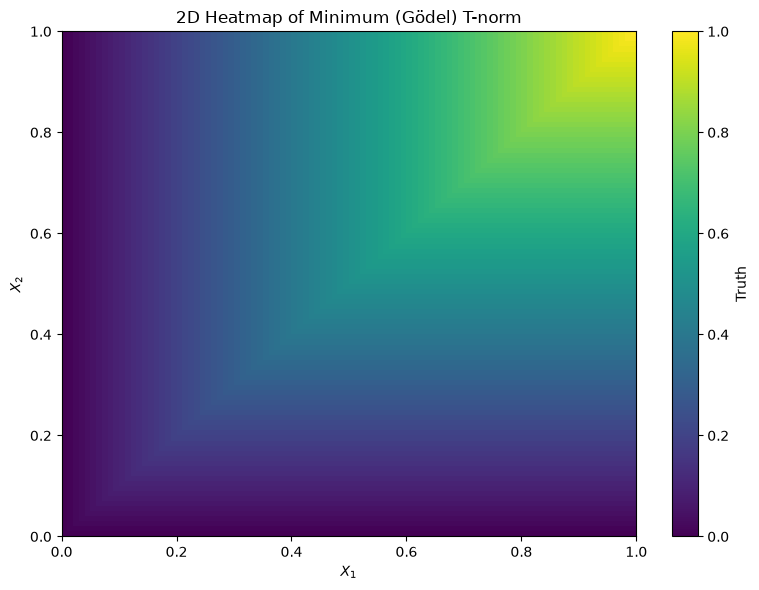

In [11]:
plot_norm_functions(x1, x2, t_norm_min, 'Minimum (Gödel) T-norm', 't_norm_min')

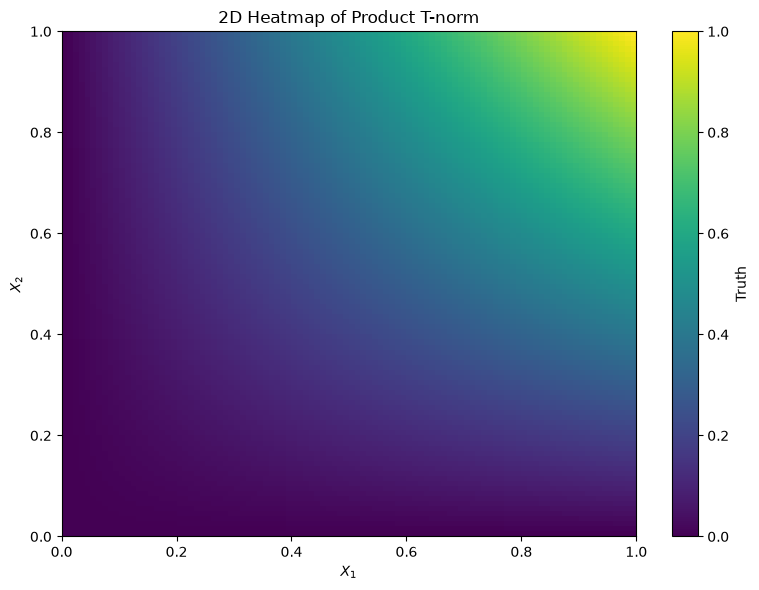

In [12]:
plot_norm_functions(x1, x2, t_norm_product, 'Product T-norm', 't_norm_product')

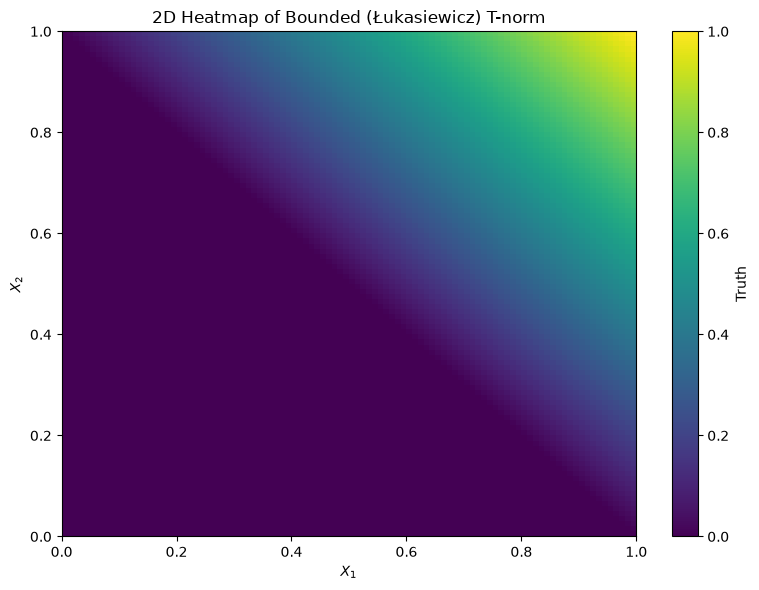

In [13]:
plot_norm_functions(x1, x2, t_norm_bounded, 'Bounded (Łukasiewicz) T-norm', 't_norm_bounded')

#### T-Conorm Plots

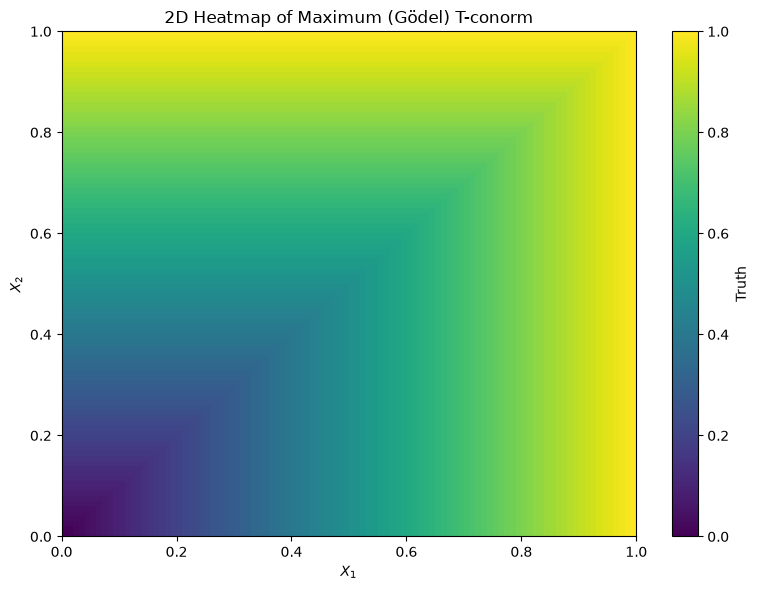

In [14]:
plot_norm_functions(x1, x2, t_conorm_maximum, 'Maximum (Gödel) T-conorm', 't_conorm_maximum')

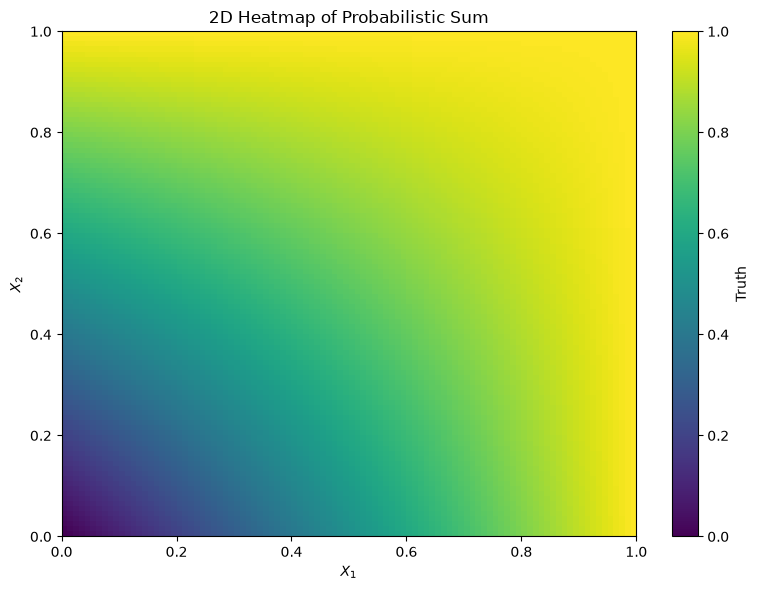

In [15]:
plot_norm_functions(x1, x2, t_conorm_sum, 'Probabilistic Sum', 't_conorm_sum')

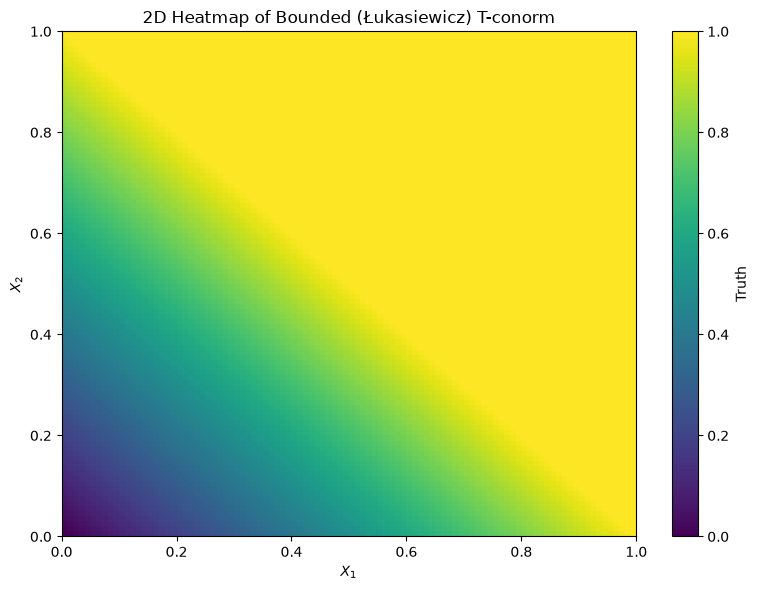

In [16]:
plot_norm_functions(x1, x2, t_conorm_bounded, 'Bounded (Łukasiewicz) T-conorm', 't_conorm_bounded')

### Negation

In [17]:
def negation(x):
    return 1.0-x

In [18]:
x = jnp.linspace(0.0, 1.0, NUM_SAMPLES)

In [19]:
def plot_norm_negation(x, negation_fn):
    neg_output = negation_fn(x)

    fig = plt.figure(figsize=(8, 6))
    
    im = plt.plot(x, neg_output, color='red')
    
    plt.xlabel('X')
    plt.ylabel('Truth')
    plt.title('Negation')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(
        'negation.png',
        bbox_inches='tight', 
        dpi=300
    )

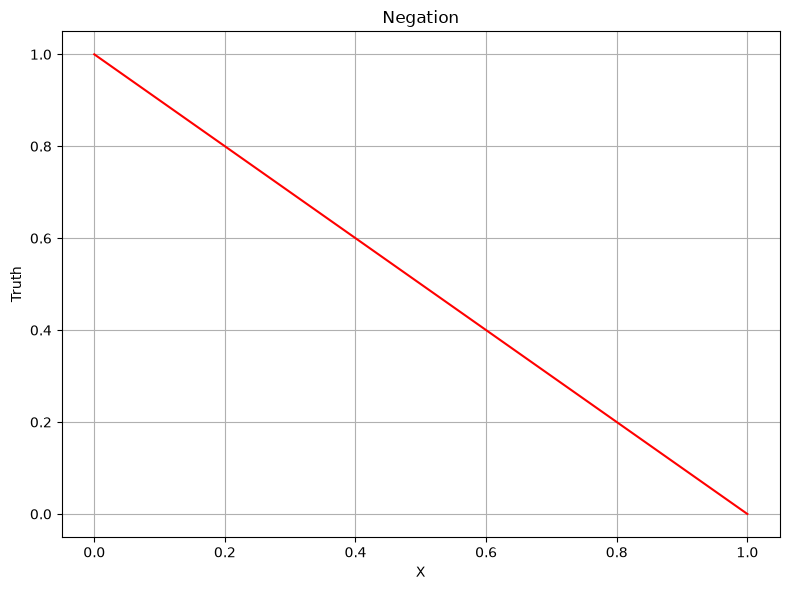

In [20]:
plot_norm_negation(x, negation)

## Differential Optimization of Truth

In [21]:
import jax.random as jrd

SEED = 1234

In [22]:
def init_logical_array(array_shape, key, noise_scale=0.1):
    noise = jrd.normal(jrd.key(key), array_shape) * noise_scale
    # any shaped array centered around 0.5
    return 0.5 * jnp.ones(array_shape) + noise

x1, x2 = init_logical_array((2,), SEED)
print(f'Initial value of X_1: {float(x1):.3f} and X_2: {float(x2):.3f}')

Initial value of X_1: 0.610 and X_2: 0.586


In [23]:
VALID_TNORM_FUNCTIONS = {
    'minimum': t_norm_min,
    'product': t_norm_product,
    'bounded': t_norm_bounded,
}

VALID_TCONORM_FUNCTIONS = {
    'maximum': t_conorm_maximum,
    'probabilistic_sum': t_conorm_sum,
    'bounded': t_conorm_bounded
}

def diff_and(x1, x2, name='product'):
    _name = name.lower().strip()
    if _name not in VALID_TNORM_FUNCTIONS.keys():
        raise ValueError(f'{name} is a valid AND realization, select from: {VALID_TNORM_FUNCTIONS.keys()}')
    selected_realization = VALID_TNORM_FUNCTIONS[_name]
    return selected_realization(x1, x2)

def diff_or(x1, x2, name='probabilistic_sum'):
    _name = name.lower().strip()
    if _name not in VALID_TCONORM_FUNCTIONS.keys():
        raise ValueError(f'{name} is a valid AND realization, select from: {VALID_TCONORM_FUNCTIONS.keys()}')
    selected_realization = VALID_TCONORM_FUNCTIONS[_name]
    return selected_realization(x1, x2)

def diff_not(x):
    # (SINGLE REALIZATION OF NOT, BUT CAN BE ADDED LATER)
    # (THIS IS FOR FUTURE COMPATIBILITY)
    return negation(x)

### Truth Function
* Evaluates the truth of a logical expression: $\mathcal{T} = X_1 \land \neg X_2$

In [24]:
def truth_fn(x1, x2):
    return diff_and(x1, diff_not(x2))

grad_fn = jax.value_and_grad(truth_fn, argnums=(0, 1))

### Training Loop

In [25]:
SEED = 1234
NUM_EPOCHS = 10
LEARNING_RATE = 1e-1

In [26]:
for epoch in range(1, NUM_EPOCHS+1):
    # CALCULATE GRADIENTS
    truth_val, (dT_dx1, dT_dx2) = grad_fn(x1, x2)

    # UPDATE VALUES USING GRADIENT ASCENT
    x1 = x1 + LEARNING_RATE*dT_dx1
    x2 = x2 + LEARNING_RATE*dT_dx2
    
    # (ENSURE LOGICAL APPROXIMATIONS IN VALID RANGE)
    x1 = jnp.clip(x1, 0.0, 1.0)
    x2 = jnp.clip(x2, 0.0, 1.0)

    print(f"{'Epoch':<6} | {'Truth':<8} | {'X_1':<8} | {'X_2':<8}")
    print(f'{epoch:<6} | {truth_val:<8.4f} | {x1:<8.4f} | {x2:<8.4f}')
    print()

Epoch  | Truth    | X_1      | X_2     
1      | 0.2525   | 0.6517   | 0.5253  

Epoch  | Truth    | X_1      | X_2     
2      | 0.3094   | 0.6992   | 0.4601  

Epoch  | Truth    | X_1      | X_2     
3      | 0.3775   | 0.7531   | 0.3902  

Epoch  | Truth    | X_1      | X_2     
4      | 0.4593   | 0.8141   | 0.3149  

Epoch  | Truth    | X_1      | X_2     
5      | 0.5578   | 0.8826   | 0.2335  

Epoch  | Truth    | X_1      | X_2     
6      | 0.6766   | 0.9593   | 0.1452  

Epoch  | Truth    | X_1      | X_2     
7      | 0.8200   | 1.0000   | 0.0493  

Epoch  | Truth    | X_1      | X_2     
8      | 0.9507   | 1.0000   | 0.0000  

Epoch  | Truth    | X_1      | X_2     
9      | 1.0000   | 1.0000   | 0.0000  

Epoch  | Truth    | X_1      | X_2     
10     | 1.0000   | 1.0000   | 0.0000  



## Binary Evaluation

In [27]:
def evaluate_binary(x1, x2):

    x1_binary = binarize(x1)
    x2_binary = binarize(x2)

    truth_binary = (x1_binary and (not x2_binary))

    print(f'Binary logic value of x_1: {bool(x1_binary)}')
    print(f'Binary logic value of x_2: {bool(x2_binary)}')
    print(f'Binary logic value of T_final: {truth_binary}')

In [28]:
evaluate_binary(x1, x2)

Binary logic value of x_1: True
Binary logic value of x_2: False
Binary logic value of T_final: True
